# $(i, i+2)$ hopping interaction

We need to implement the next to nearest neighbours interaction for the hopping term.
Let us try three strategies:
1. do a simple $(i,i+1)$ interaction with the correct parameters and insert _a posteriori_ an identity MPO
2. make two sequential svds to obtain a three-site mpo (careful with the canonical form).
3. use the swap gate technique implemented by E. M. Stoudenmire and Steven R. White

In [38]:
%load_ext autoreload
%autoreload 2

import numpy as np

from ncon import ncon

from scipy.sparse import csc_array, kron
import scipy.sparse as sp
from scipy.linalg import svd

from qs_mps.utils import tensor_shapes, mpo_to_matrix, create_sequential_colors
from qs_mps.applications.tJ.ed_ham import *

import matplotlib.pyplot as plt

# default parameters of the plot layout
plt.rcParams["text.usetex"] = True  # use latex
plt.rcParams["font.size"] = 13
plt.rcParams["figure.dpi"] = 300
plt.rcParams["figure.constrained_layout.use"] = True

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
def swap_gate(d):
    W = np.zeros((d,d,d,d), dtype=int)
    for i in range(d):
        for j in range(d):
            W[j,i,i,j] = 1
    return W

swap_mpo = swap_gate(3)

In [7]:
def id_gate(d,chi):
    I = np.zeros((chi, chi, d, d))

    for a in range(chi):
        for s in range(d):
            I[a,a,s,s] = 1.0
    return I

I_mpo = id_gate(3,9)

In [5]:
# Single-site identity
Id = sp.identity(3, format="csr").toarray()
O = csc_array((3, 3), dtype=complex).toarray()

# Spin operators
Sz = (1/2) * sp.diags([1, 0, -1], 0, format="csr")

S_plus  = sp.csr_matrix([[0, 0, 1],
                         [0, 0, 0],
                         [0, 0, 0]])

S_minus = sp.csr_matrix([[0, 0, 0],
                         [0, 0, 0],
                         [1, 0, 0]])

# Hole hopping operators

# hole goes into a spin up state
T_up_h   = sp.csr_matrix([[0, 1, 0],
                          [0, 0, 0],
                          [0, 0, 0]])

# hole goes into a spin down state
T_down_h = sp.csr_matrix([[0, 0, 0],
                          [0, 0, 0],
                          [0, 1, 0]])

# spin up goes into a hole state
T_h_up   = sp.csr_matrix([[0, 0, 0],
                          [1, 0, 0],
                          [0, 0, 0]])

# spin down goes into a hole state
T_h_down = sp.csr_matrix([[0, 0, 0],
                          [0, 0, 1],
                          [0, 0, 0]])

# Hole number operator
n_h = sp.csr_matrix([[0, 0, 0],
                     [0, 1, 0],
                     [0, 0, 0]])

### $1 \quad (i,i+1)$ interaction plus _a posteriori_ identity mpo

We make the evolution following these steps:
1. (a) define parameters of the $(i,i+2)$ interaction
1. (b) exponentiate the hopping operators in the space of two sites using time step $\delta$ or $\delta /2$ for the 2nd order trotterization
1. (c) divide the left and right part of this two-site operator with svd
1. (d) separate the possible interactions in four families $(A,B,C,D)$. In which $(A,B)$ are even and do NOT commute within each other, and $(C,D)$ are odd and do not commute with each other. However, $[A,C]=[A,D]=0$. Thus, we can organize our trotter steps as $U(\delta / 2 AC)  U(\delta BD) U (\delta / 2 AC)$ with in total only three contractions needed with the mps.

To realize 1. (d), we need to contract the mpo of $A$ with the mpo of $C$, and the mpo of $B$ with the mpo of $D$, respectively. We do so by creating masks that tell us where are the operators that contract with each others, if any

### 1.(a)

In [2]:
# parameters for the (i,i+2) interaction
half_chain_length = 3
tp_up, tp_down = 16, 16
trotter_steps = 100
final_time = 2
delta = final_time/trotter_steps
n = 2*half_chain_length + 1

### 1.(b)

In [8]:
## helping functions
def U_i_ip2_tJ(tp_up, tp_down, delta):
    """
    U_i_ip2

    This function computes the exponential of the 2-site hamiltonian for the t-J model.
    It returns to versions: 
    1. one with a time step delta/2 to use at the initial and final step
    of the trotterization
    2. one with a time step delta to use in the bulk steps of the trotterization

    """

    # choose the hamiltonian parameters
    H_i_ip2 = (
    - (tp_up/8) * kron(T_up_h, T_h_up) 
    - (tp_up/8) * kron(T_h_up, T_up_h)
    - (tp_down/8) * kron(T_down_h, T_h_down) 
    - (tp_down/8) * kron(T_h_down, T_down_h)).toarray()

    # initial and final 2-site evolution operator
    op_ev_if = sp.linalg.expm(-1j * delta/2 * H_i_ip2)

    # bulk 2-site evolution operator
    op_ev_bulk = sp.linalg.expm(-1j * delta * H_i_ip2)
    
    return op_ev_if, op_ev_bulk

def evolution_mpo_svd_1_tJ(op_ev: np.ndarray, d: int=3, schmidt_tol: float=1e-15, trunc: bool=False):
    """
    evolution_mpo_svd

    This function takes the edges, and bulk 2-site evolution operators (of the t-J model) and performs an svd
    to separate the matrix into site i and site i+1. Reshaping the results of the svd
    we can obtain the mpo for those evolution operators (with bounded bond dimension D<=d^2)

    """
    op_ev = op_ev.reshape(d,d,d,d)
    op_ev = op_ev.transpose(0,2,1,3)
    op_ev = op_ev.reshape(d*d,d*d)

    u, s, v = svd(op_ev, full_matrices=False)

    if trunc:
        condition = s >= schmidt_tol
        s_trunc = np.extract(condition, s)
        s = s_trunc
        v = v[:len(s),:]

    site_i = u.reshape(d,d,u.shape[1])
    site_i = site_i[:, :, :len(s)]
    site_i = site_i.transpose(2,0,1)
    site_i = site_i.reshape(1,len(s),d,d)

    site_ip1 = ncon([np.diag(s), v],[[-1, 1],[1, -2]]).reshape(v.shape[0],d,d)
    site_ip1 = site_ip1.reshape(1,v.shape[0],d,d)
    site_ip1 = site_ip1.transpose(1,0,2,3)


    tol = 1e-15 * np.max(np.abs(site_i))
    site_i.real[np.abs(site_i.real) < tol] = 0
    site_i.imag[np.abs(site_i.imag) < tol] = 0
    
    tol = 1e-15 * np.max(np.abs(site_ip1))
    site_ip1.real[np.abs(site_ip1.real) < tol] = 0
    site_ip1.imag[np.abs(site_ip1.imag) < tol] = 0
    
    return site_i, site_ip1

In [9]:
# exponentials of a two-site matrix with delta of delta/2
op_ev_half, op_ev_delta = U_i_ip2_tJ(tp_up, tp_down, delta)

### 1.(c)

In [10]:
# with SVD get the left and right part for A,B,C,D with the enlarged identity
site_i_delta_half, site_ip2_delta_half = evolution_mpo_svd_1_tJ(op_ev_half)
site_i_delta, site_ip2_delta = evolution_mpo_svd_1_tJ(op_ev_delta)
tensor_shapes([site_i_delta_half, site_ip2_delta_half])
id_enlarged_mpo = id_gate(3,site_i_delta_half.shape[1])

(1, 9, 3, 3)
(9, 1, 3, 3)


### 1.(d)

In [11]:
## helping functions
def make_mask_even(n):
    mask_id_A = [(i%4 == 1) if (i+1)<n else False for i in range(n)]
    mask_C_l = [(i%4 == 1) if (i+2)<n else False for i in range(n)]
    return mask_id_A, mask_C_l

def make_mask_odd(n):
    mask_id_B = [(i%4 == 3) if (i+1)<n else False for i in range(n)]
    mask_D_l = [(i%4 == 3) if (i+2)<n else False for i in range(n)]
    return mask_id_B, mask_D_l

def make_trott_mpo(n, op_l, i_en, op_r, id, parity: str="even", d: int=3):
    if parity == "even":
        mask_1, mask_2 = make_mask_even(n)
    elif parity == "odd":
        mask_1, mask_2 = make_mask_odd(n)

    mpo_trott = [id] * n

    idx = 0
    for mask_step_1, mask_step_2 in zip(mask_1, mask_2):
        if mask_step_1:
            mpo_trott[idx] = i_en.copy()
            mpo_trott[idx-1] = op_l.copy()
            mpo_trott[idx+1] = op_r.copy()
        if mask_step_2:
            mpo_trott[idx] = ncon([mpo_trott[idx],op_l],[[-1,-3,-5,1],[-2,-4,1,-6]]).reshape((mpo_trott[idx].shape[0],mpo_trott[idx].shape[1]*op_l.shape[1],d,d))
            mpo_trott[idx+1] = ncon([mpo_trott[idx+1],i_en],[[-1,-3,-5,1],[-2,-4,1,-6]]).reshape((mpo_trott[idx+1].shape[0]*i_en.shape[0],i_en.shape[1],d,d))
            mpo_trott[idx+2] = op_r.copy()
        idx += 1
    return mpo_trott

In [12]:
id_mpo = sp.identity(n=3).toarray().reshape((1,1,3,3))
print(id_mpo.shape)
trotter_step_delta_half = make_trott_mpo(n, site_i_delta_half, id_enlarged_mpo, site_ip2_delta_half, id_mpo, parity="even")
trotter_step_delta = make_trott_mpo(n, site_i_delta, id_enlarged_mpo, site_ip2_delta, id_mpo, parity="odd")
tensor_shapes(trotter_step_delta_half, prnt=False), tensor_shapes(trotter_step_delta,prnt=False)

(1, 1, 3, 3)


([(1, 9, 3, 3),
  (9, 81, 3, 3),
  (81, 9, 3, 3),
  (9, 1, 3, 3),
  (1, 9, 3, 3),
  (9, 9, 3, 3),
  (9, 1, 3, 3)],
 [(1, 1, 3, 3),
  (1, 1, 3, 3),
  (1, 9, 3, 3),
  (9, 81, 3, 3),
  (81, 9, 3, 3),
  (9, 1, 3, 3),
  (1, 1, 3, 3)])

In [24]:
def trotter_step_pipeline(n, tp_up, tp_down, delta):
    op_ev_half, op_ev_delta = U_i_ip2_tJ(tp_up, tp_down, delta)
    site_i_delta_half, site_ip2_delta_half = evolution_mpo_svd_1_tJ(op_ev_half)
    site_i_delta, site_ip2_delta = evolution_mpo_svd_1_tJ(op_ev_delta)
    id_enlarged_mpo = id_gate(3,site_i_delta_half.shape[1])
    id_mpo = sp.identity(n=3).toarray().reshape((1,1,3,3))
    trotter_step_delta_half = make_trott_mpo(n, site_i_delta_half, id_enlarged_mpo, site_ip2_delta_half, id_mpo, parity="even")
    trotter_step_delta = make_trott_mpo(n, site_i_delta, id_enlarged_mpo, site_ip2_delta, id_mpo, parity="odd")
    return trotter_step_delta_half, trotter_step_delta

## Convert to matrix to make a quick test

In [25]:
half_chain_length = 3
tp_up, tp_down = 16, 16
trotter_steps = 100
final_time = 2
delta = final_time/trotter_steps
n = 2*half_chain_length + 1

In [13]:
U_half = mpo_to_matrix(trotter_step_delta_half)
U_delta = mpo_to_matrix(trotter_step_delta)

U_step = U_half @ U_delta @ U_half

In [33]:
half_chain_length = 3
t_up = 0
t_down = 0
Jz = 10
J_perp = 0
eps = 0
V = 0
trotter_steps = 100
final_time = 2
delta = final_time / trotter_steps

In [40]:
H_ev, psi_init = half_hole_quench_init(half_chain_length, t_up, t_down, Jz, J_perp, eps, V, n_holes=1)

occup_tot_nnn = []
for tp_up in [0,1,4,8,16]:
    tp_down = tp_up
    trotter_step_delta_half, trotter_step_delta = trotter_step_pipeline(n, tp_up, tp_down, delta)
    U_half = mpo_to_matrix(trotter_step_delta_half)
    U_delta = mpo_to_matrix(trotter_step_delta)

    U_step = U_half @ U_delta @ U_half

    psi_ev = psi_init.copy()

    obs = ['h_loc', 'm_loc']
    ops_h = local_hole_occupation(n)
    ops_m = local_mag_occupation(n)

    occup_tot_h = []
    occup_tot_m = []

    for t in range(trotter_steps):
        print(f"trotter step: {t}")
        
        psi_ev = U_step @ psi_ev

        if 'h_loc' in obs:
            occup = []
            for op in ops_h:
                occup.append((psi_ev.conjugate().T @ op @ psi_ev).real)
                # occup.append(((psi_ev.conjugate().T @ op @ psi_ev).real).toarray())
            occup_tot_h.append(occup)

        if 'm_loc' in obs:
            occup = []
            for op in ops_m:
                occup.append((psi_ev.conjugate().T @ op @ psi_ev).real)
                # occup.append(((psi_ev.conjugate().T @ op @ psi_ev).real).toarray())
            occup_tot_m.append(occup)
    occup_tot_nnn.append(occup_tot_h)

trotter step: 0
trotter step: 1
trotter step: 2
trotter step: 3
trotter step: 4
trotter step: 5
trotter step: 6
trotter step: 7
trotter step: 8
trotter step: 9
trotter step: 10
trotter step: 11
trotter step: 12
trotter step: 13
trotter step: 14
trotter step: 15
trotter step: 16
trotter step: 17
trotter step: 18
trotter step: 19
trotter step: 20
trotter step: 21
trotter step: 22
trotter step: 23
trotter step: 24
trotter step: 25
trotter step: 26
trotter step: 27
trotter step: 28
trotter step: 29
trotter step: 30
trotter step: 31
trotter step: 32
trotter step: 33
trotter step: 34
trotter step: 35
trotter step: 36
trotter step: 37
trotter step: 38
trotter step: 39
trotter step: 40
trotter step: 41
trotter step: 42
trotter step: 43
trotter step: 44
trotter step: 45
trotter step: 46
trotter step: 47
trotter step: 48
trotter step: 49
trotter step: 50
trotter step: 51
trotter step: 52
trotter step: 53
trotter step: 54
trotter step: 55
trotter step: 56
trotter step: 57
trotter step: 58
trotter

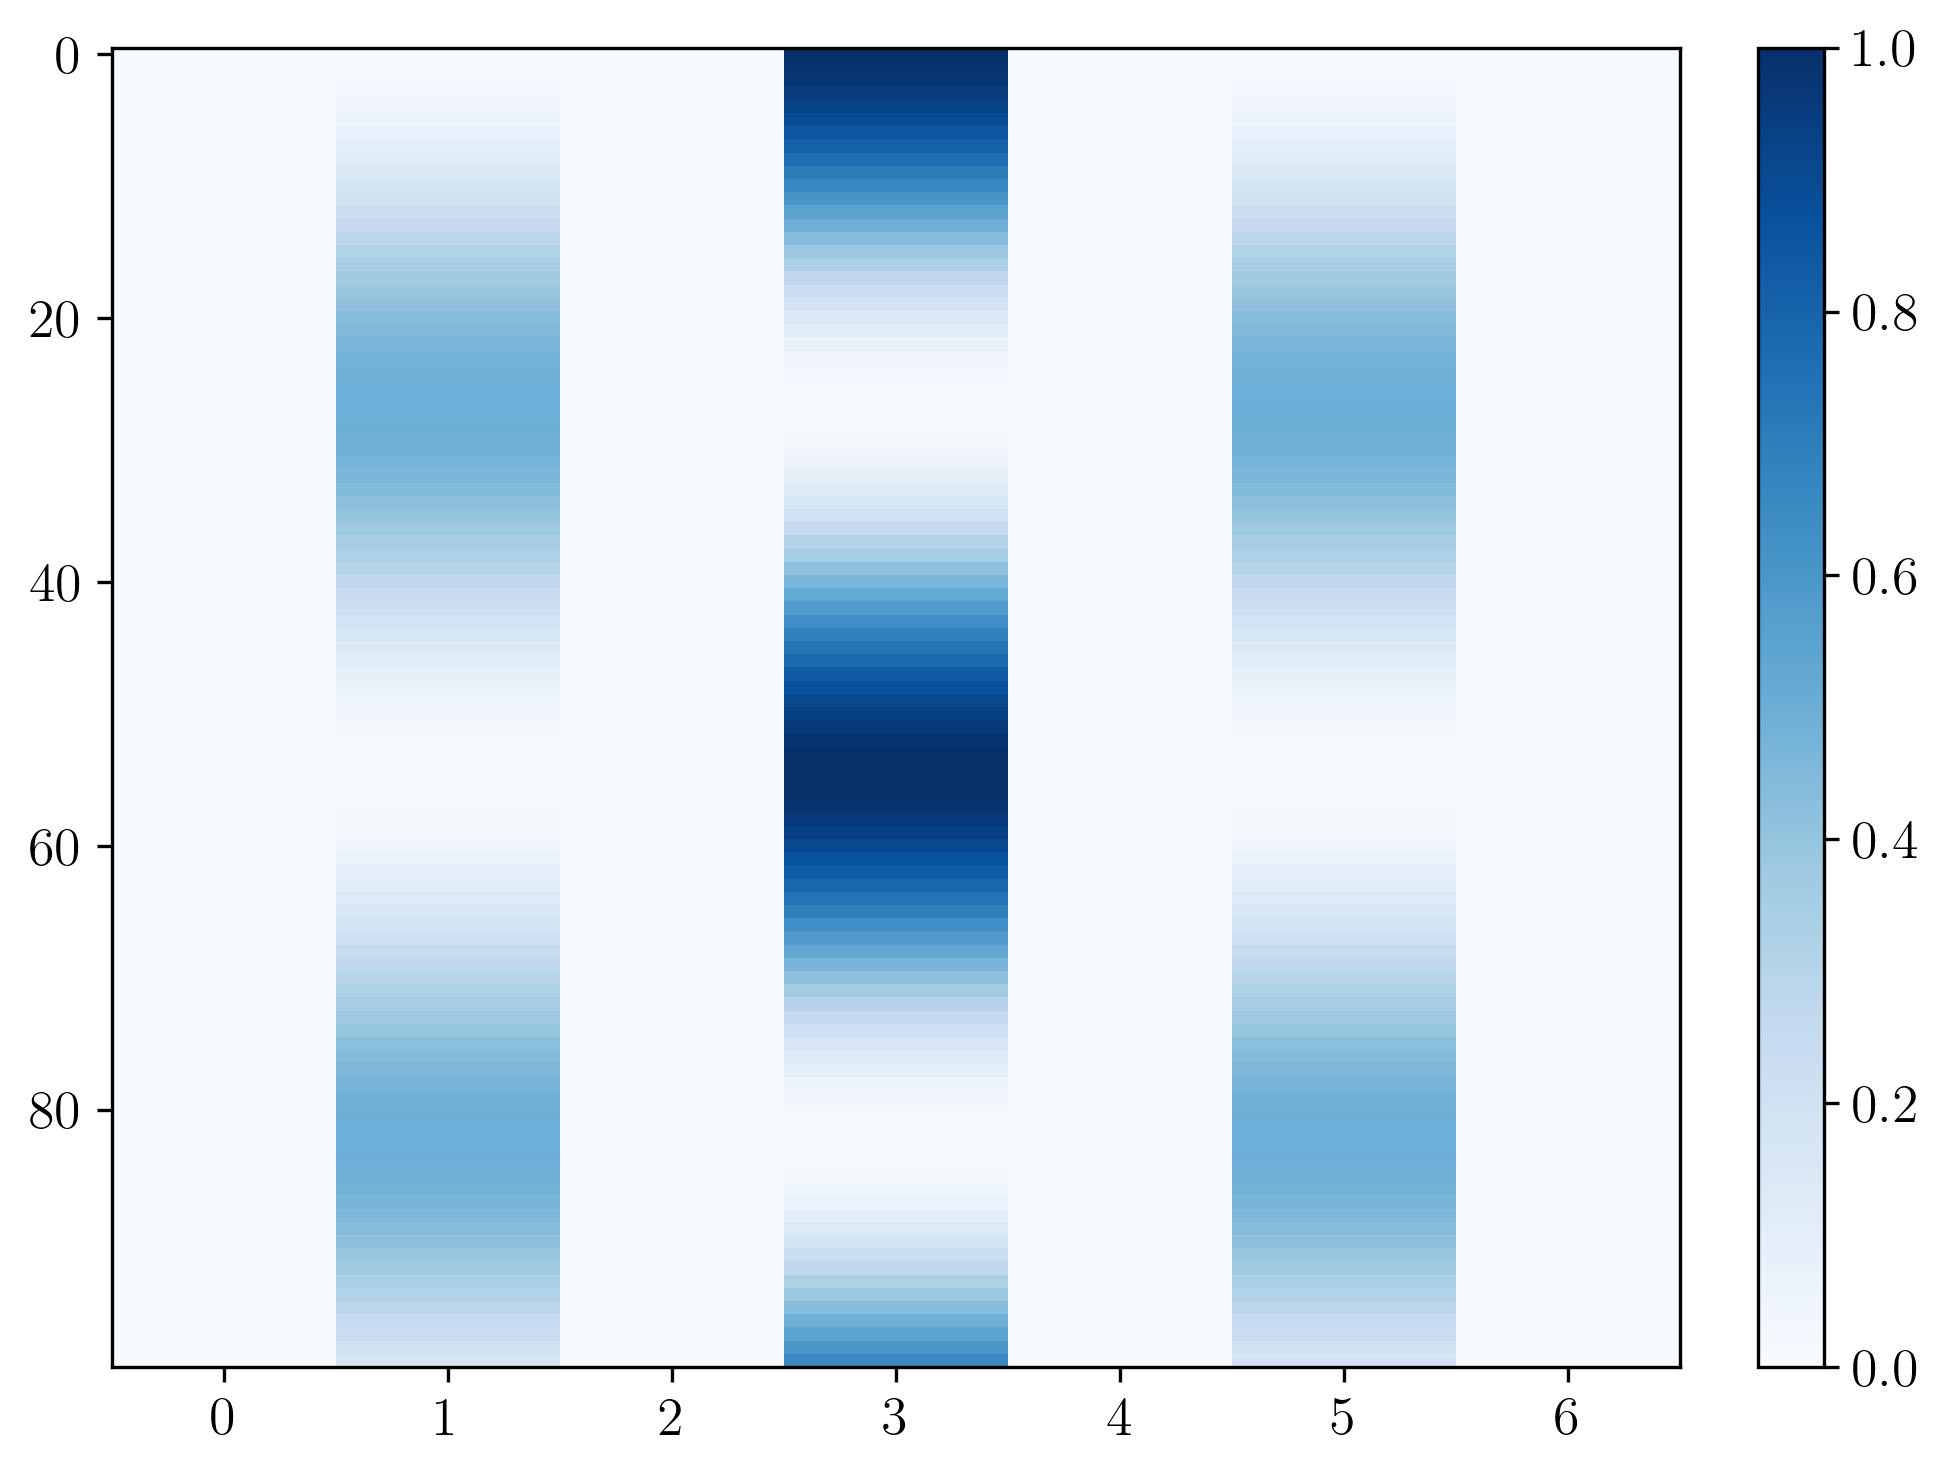

In [35]:
plt.imshow(np.asarray(occup_tot_h), vmin=0, vmax=1, aspect='auto', cmap="Blues")
plt.colorbar()

Trotter step: 0
Trotter step: 1
Trotter step: 2
Trotter step: 3
Trotter step: 4
Trotter step: 5
Trotter step: 6
Trotter step: 7
Trotter step: 8
Trotter step: 9
Trotter step: 10
Trotter step: 11
Trotter step: 12
Trotter step: 13
Trotter step: 14
Trotter step: 15
Trotter step: 16
Trotter step: 17
Trotter step: 18
Trotter step: 19
Trotter step: 20
Trotter step: 21
Trotter step: 22
Trotter step: 23
Trotter step: 24
Trotter step: 25
Trotter step: 26
Trotter step: 27
Trotter step: 28
Trotter step: 29
Trotter step: 30
Trotter step: 31
Trotter step: 32
Trotter step: 33
Trotter step: 34
Trotter step: 35
Trotter step: 36
Trotter step: 37
Trotter step: 38
Trotter step: 39
Trotter step: 40
Trotter step: 41
Trotter step: 42
Trotter step: 43
Trotter step: 44
Trotter step: 45
Trotter step: 46
Trotter step: 47
Trotter step: 48
Trotter step: 49
Trotter step: 50
Trotter step: 51
Trotter step: 52
Trotter step: 53
Trotter step: 54
Trotter step: 55
Trotter step: 56
Trotter step: 57
Trotter step: 58
Trotter

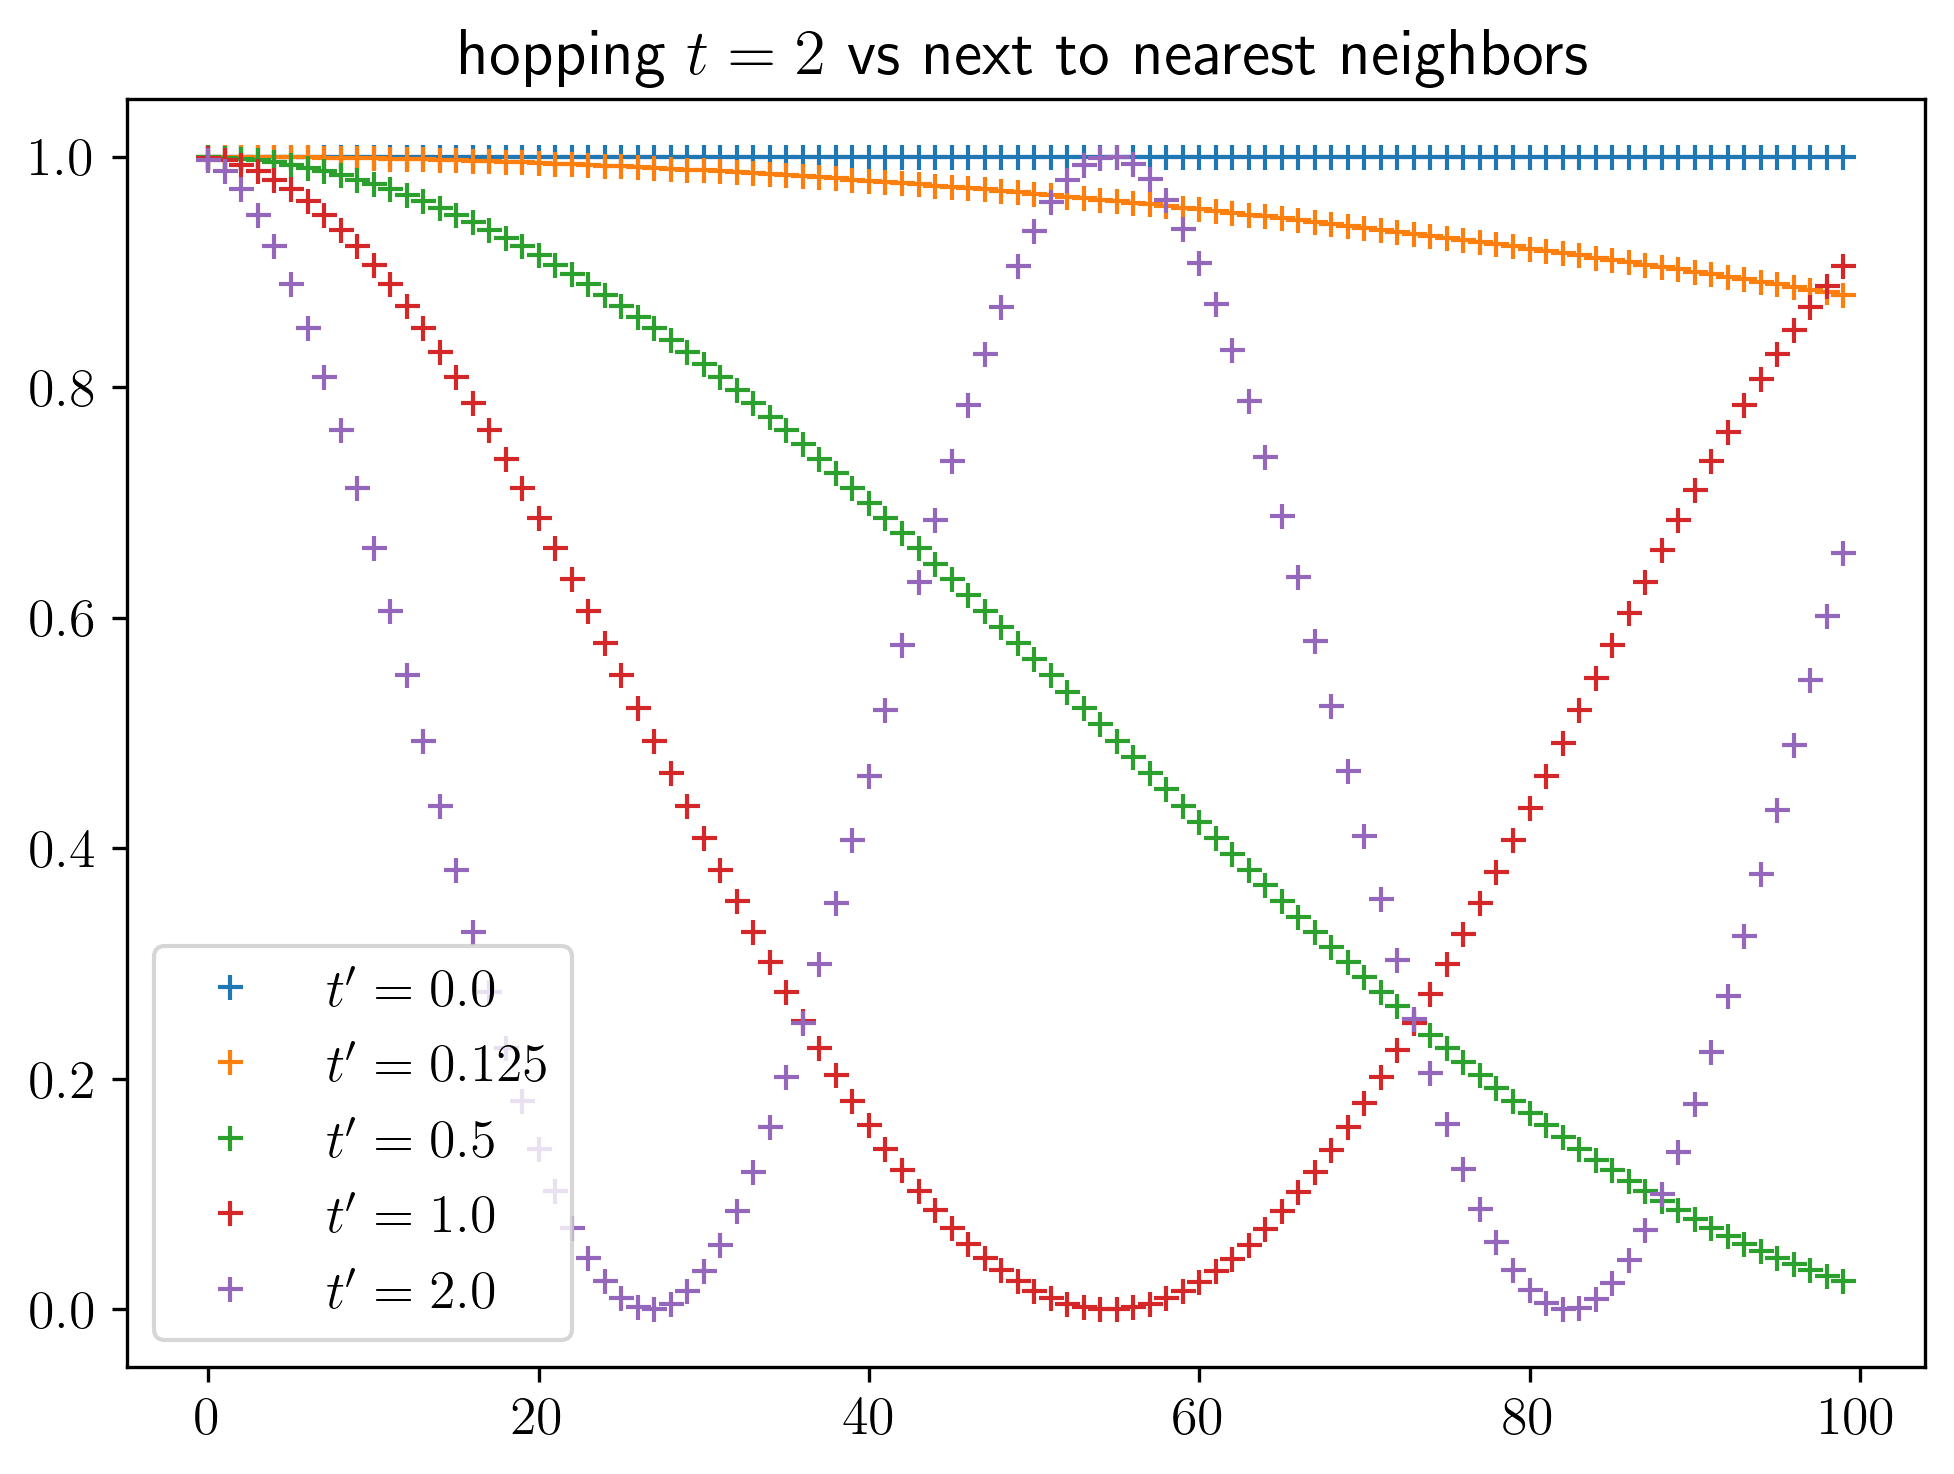

In [36]:
tp_ups = [0,1,4,8,16]
tp_downs = [0,1,4,8,16]
for tp_up, tp_down in zip(tp_ups, tp_downs):
    H_ev, psi_init = half_hole_quench_init(half_chain_length, t_up, t_down, Jz, J_perp, eps, V, tp_up=tp_up, tp_down=tp_down)
    occup_tot, _ = half_hole_quench_evolution(half_chain_length, H_ev, psi_init, trotter_steps, final_time)
    plt.plot(np.asarray(occup_tot[0])[:,3],'+', label=f'$t\' ={tp_up/8}$')

plt.title("hopping $t=2$ vs next to nearest neighbors")
plt.legend()

Trotter step: 0
Trotter step: 1
Trotter step: 2
Trotter step: 3
Trotter step: 4
Trotter step: 5
Trotter step: 6
Trotter step: 7
Trotter step: 8
Trotter step: 9
Trotter step: 10
Trotter step: 11
Trotter step: 12
Trotter step: 13
Trotter step: 14
Trotter step: 15
Trotter step: 16
Trotter step: 17
Trotter step: 18
Trotter step: 19
Trotter step: 20
Trotter step: 21
Trotter step: 22
Trotter step: 23
Trotter step: 24
Trotter step: 25
Trotter step: 26
Trotter step: 27
Trotter step: 28
Trotter step: 29
Trotter step: 30
Trotter step: 31
Trotter step: 32
Trotter step: 33
Trotter step: 34
Trotter step: 35
Trotter step: 36
Trotter step: 37
Trotter step: 38
Trotter step: 39
Trotter step: 40
Trotter step: 41
Trotter step: 42
Trotter step: 43
Trotter step: 44
Trotter step: 45
Trotter step: 46
Trotter step: 47
Trotter step: 48
Trotter step: 49
Trotter step: 50
Trotter step: 51
Trotter step: 52
Trotter step: 53
Trotter step: 54
Trotter step: 55
Trotter step: 56
Trotter step: 57
Trotter step: 58
Trotter

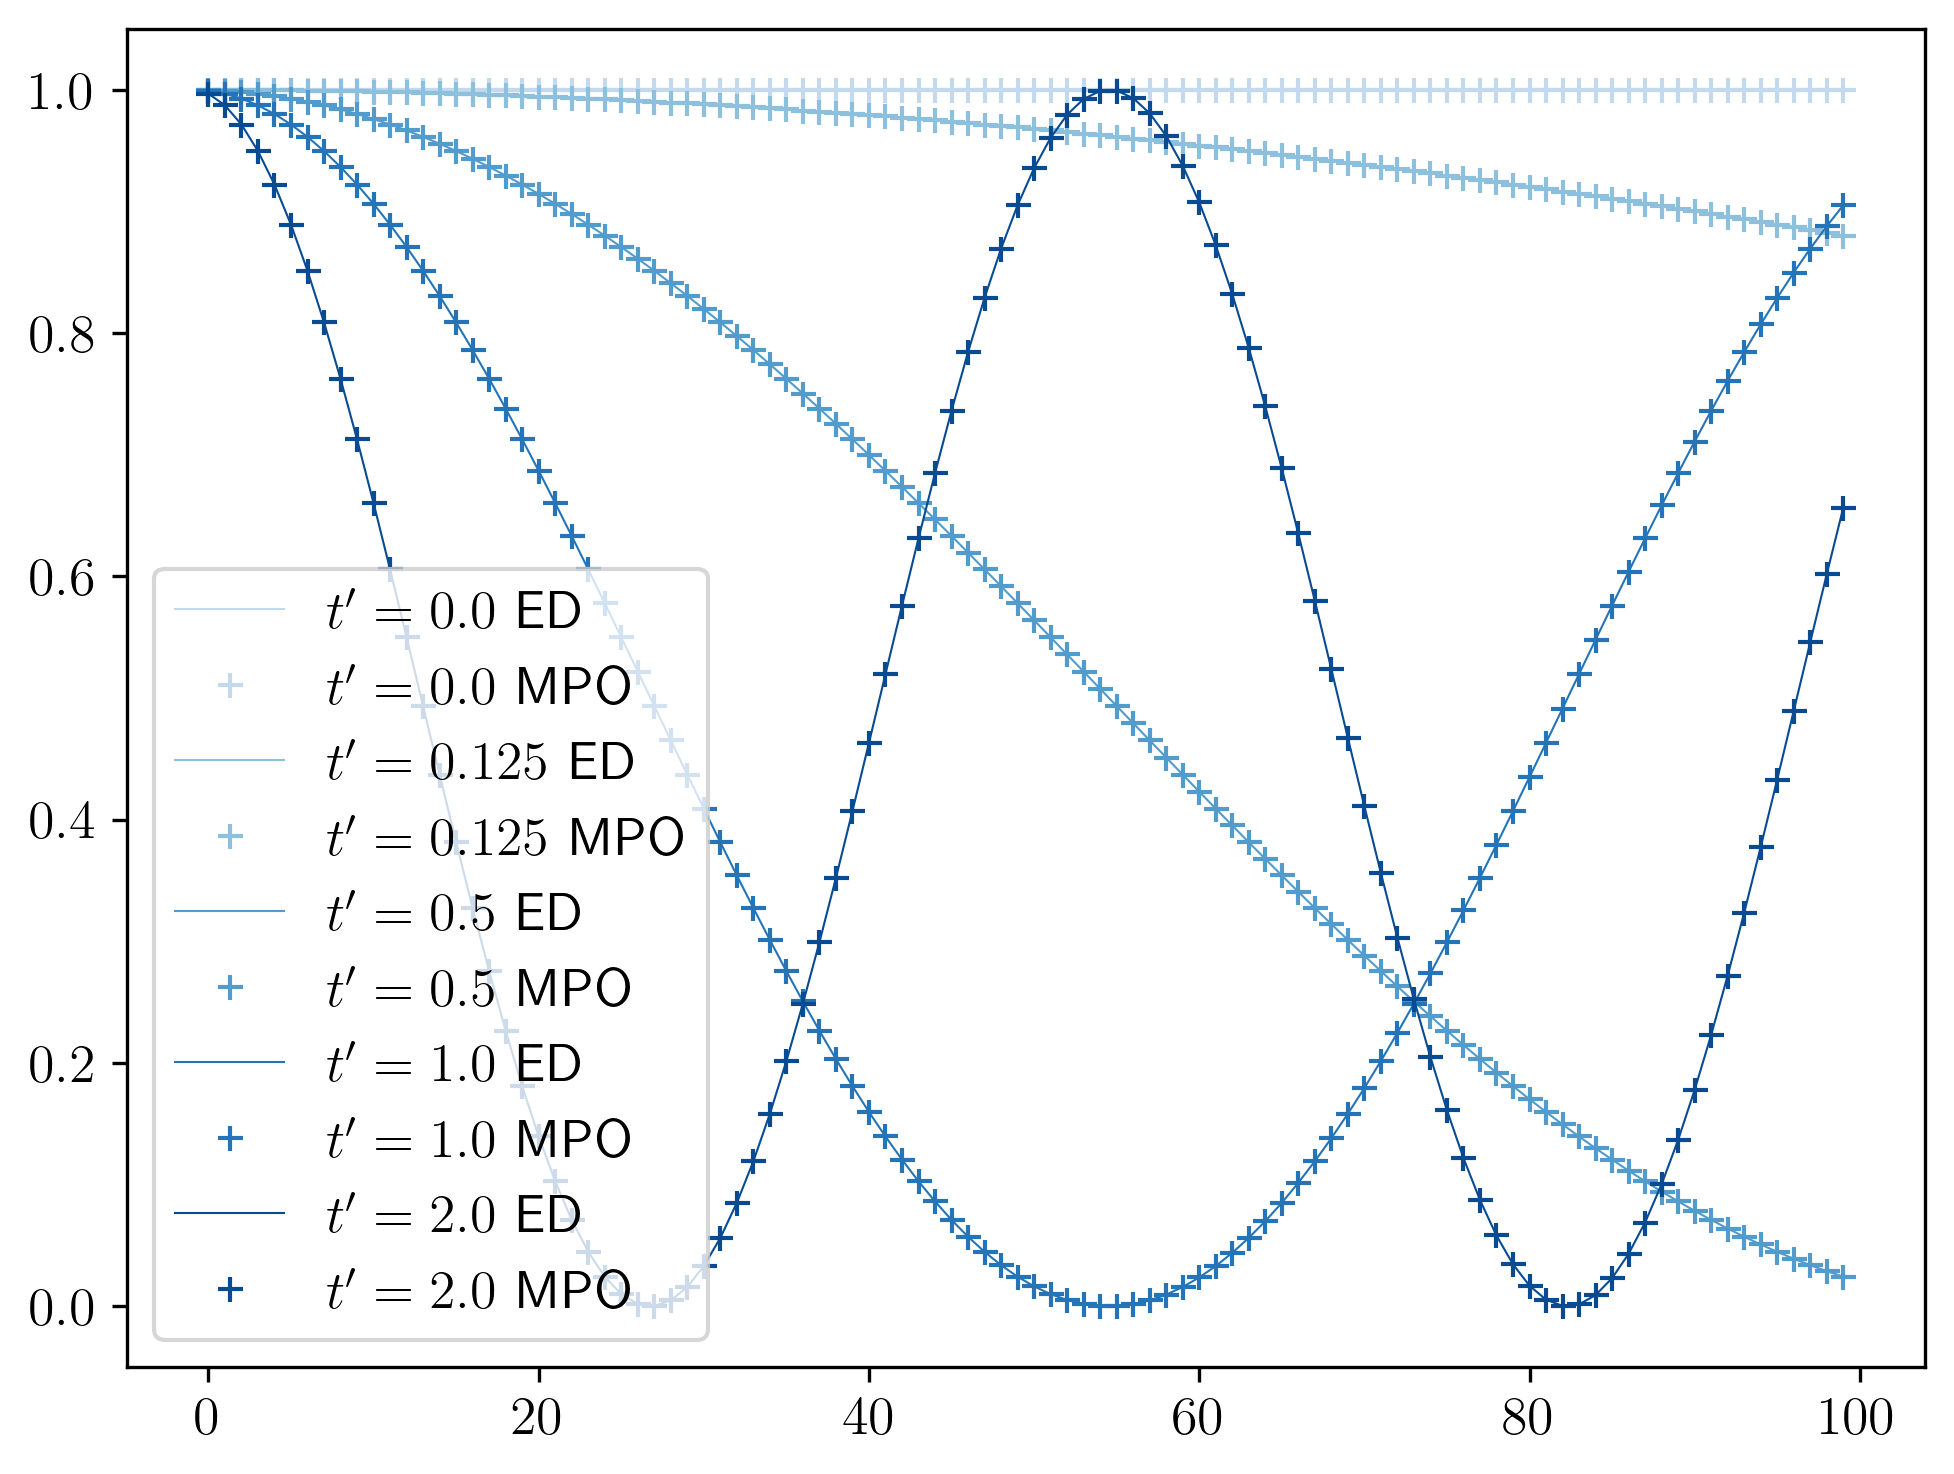

In [45]:
i = 0
colors = create_sequential_colors(len(tp_ups)*4, colormap_name='Blues')
for tp_up, tp_down in zip(tp_ups, tp_downs):
    H_ev, psi_init = half_hole_quench_init(half_chain_length, t_up, t_down, Jz, J_perp, eps, V, tp_up=tp_up, tp_down=tp_down)
    occup_tot, _ = half_hole_quench_evolution(half_chain_length, H_ev, psi_init, trotter_steps, final_time)
    plt.plot(np.asarray(occup_tot[0])[:,3], '-', color=colors[2*i+5+i], linewidth=0.5, label=f'$t\' ={tp_up/8}$ ED')
    plt.plot(np.asarray(occup_tot_nnn[i])[:,3], '+', color=colors[2*i+5+i], label=f'$t\' ={tp_up/8}$ MPO')
    i += 1
plt.legend()

Trotter step: 0
Trotter step: 1
Trotter step: 2
Trotter step: 3
Trotter step: 4
Trotter step: 5
Trotter step: 6
Trotter step: 7
Trotter step: 8
Trotter step: 9
Trotter step: 10
Trotter step: 11
Trotter step: 12
Trotter step: 13
Trotter step: 14
Trotter step: 15
Trotter step: 16
Trotter step: 17
Trotter step: 18
Trotter step: 19
Trotter step: 20
Trotter step: 21
Trotter step: 22
Trotter step: 23
Trotter step: 24
Trotter step: 25
Trotter step: 26
Trotter step: 27
Trotter step: 28
Trotter step: 29
Trotter step: 30
Trotter step: 31
Trotter step: 32
Trotter step: 33
Trotter step: 34
Trotter step: 35
Trotter step: 36
Trotter step: 37
Trotter step: 38
Trotter step: 39
Trotter step: 40
Trotter step: 41
Trotter step: 42
Trotter step: 43
Trotter step: 44
Trotter step: 45
Trotter step: 46
Trotter step: 47
Trotter step: 48
Trotter step: 49
Trotter step: 50
Trotter step: 51
Trotter step: 52
Trotter step: 53
Trotter step: 54
Trotter step: 55
Trotter step: 56
Trotter step: 57
Trotter step: 58
Trotter

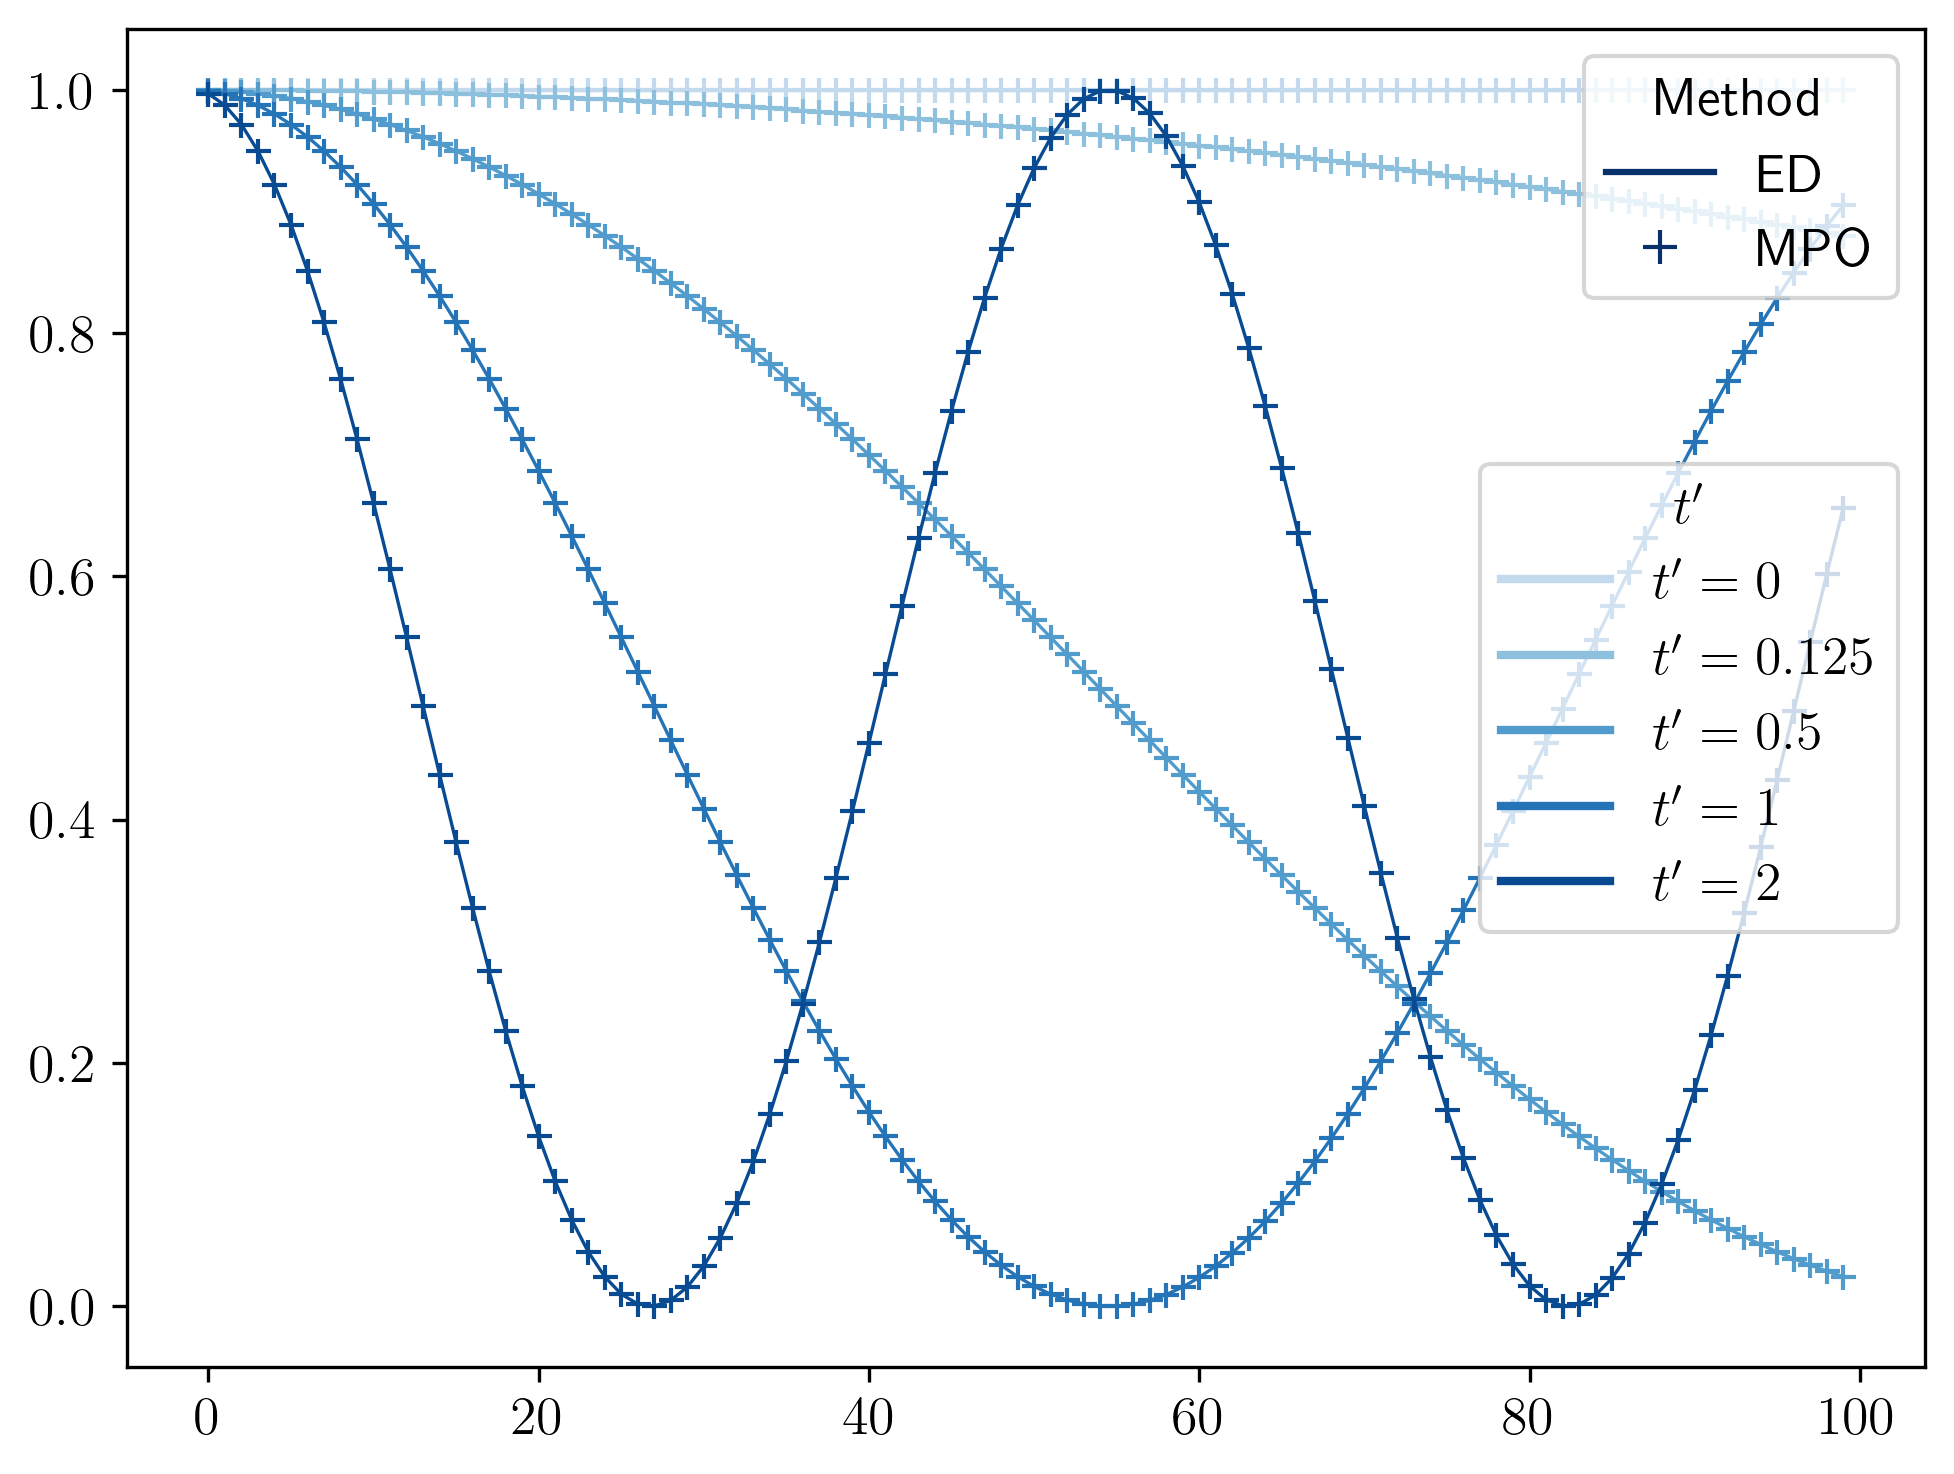

In [47]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np

fig, ax = plt.subplots()

# colormap for the parameter sweep
tp_vals = np.array(tp_ups) / 8
colors = create_sequential_colors(len(tp_vals)*4, colormap_name='Blues')

# --- Plot data ---
for i, (tp_up, tp_down) in enumerate(zip(tp_ups, tp_downs)):
    H_ev, psi_init = half_hole_quench_init(
        half_chain_length, t_up, t_down, Jz, J_perp, eps, V,
        tp_up=tp_up, tp_down=tp_down
    )

    occup_tot, _ = half_hole_quench_evolution(
        half_chain_length, H_ev, psi_init, trotter_steps, final_time
    )

    c = colors[i+5+2*i]

    # ED = line
    ax.plot(
        np.asarray(occup_tot[0])[:, 3],
        '-',
        color=c,
        linewidth=0.8
    )

    # MPO = marker
    ax.plot(
        np.asarray(occup_tot_nnn[i])[:, 3],
        '+',
        color=c,
        markersize=6
    )

# ---------------------------------------------------
# Legend 1: meaning of style (ED vs MPO)
# use dark color for visibility
dark = colors[-1]

style_handles = [
    mlines.Line2D([], [], color=dark, linestyle='-', linewidth=1.5, label='ED'),
    mlines.Line2D([], [], color=dark, linestyle='None', marker='+', markersize=8, label='MPO')
]

leg1 = ax.legend(handles=style_handles, loc='upper right', title='Method')
ax.add_artist(leg1)

# ---------------------------------------------------
# Legend 2: parameter values t'
param_handles = [
    mlines.Line2D([], [], color=colors[i+5+2*i], linewidth=2,
                  label=fr"$t'={tp_vals[i]:.3g}$")
    for i in range(len(tp_vals))
]

ax.legend(handles=param_handles, loc='center right', title=r"$t'$")

plt.show()
